In [330]:
# Imports

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
from ydata_profiling import ProfileReport

In [331]:
# Constants
DATA_TRAIN_PATH = "train.csv"
DATA_TEST_PATH = "test.csv"
TARGET_COLUMN = "SalePrice"
SUBMISSION_OUTPUT_PATH = "submission.csv"

In [332]:
# Loading and quick pre-cleaning
df_train = pd.read_csv(DATA_TRAIN_PATH)
df_train.replace('?', np.nan, inplace=True)
df_train = df_train.infer_objects()

df_test = pd.read_csv(DATA_TEST_PATH)
df_test.replace('?', np.nan, inplace=True)
df_test = df_test.infer_objects()
test_ids = df_test['Id'].copy()

In [333]:
# Exploring the dataset
df_train.head(4)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000


In [334]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [335]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [336]:
# Dropping the id column as it is not useful for prediction
df_train.drop(columns=['Id'], inplace=True)
df_test.drop(columns=['Id'], inplace=True)

In [337]:
# Feature Engineering and Preprocessing
def add_engineered_features(df):
    df = df.copy()

    df['TotalSF'] = (
        df['TotalBsmtSF'].fillna(0)
        + df['1stFlrSF'].fillna(0)
        + df['2ndFlrSF'].fillna(0)
    )
    df['TotalBathrooms'] = (
        df['FullBath'].fillna(0)
        + 0.5 * df['HalfBath'].fillna(0)
        + df['BsmtFullBath'].fillna(0)
        + 0.5 * df['BsmtHalfBath'].fillna(0)
    )
    df['TotalPorchSF'] = (
        df['OpenPorchSF'].fillna(0)
        + df['3SsnPorch'].fillna(0)
        + df['EnclosedPorch'].fillna(0)
        + df['ScreenPorch'].fillna(0)
        + df['WoodDeckSF'].fillna(0)
    )
    df['TotalRooms'] = df['TotRmsAbvGrd'].fillna(0) + df['BedroomAbvGr'].fillna(0)

    df['HouseAge'] = (df['YrSold'] - df['YearBuilt']).clip(lower=0)
    df['RemodAge'] = (df['YrSold'] - df['YearRemodAdd']).clip(lower=0)
    df['GarageAge'] = (df['YrSold'] - df['GarageYrBlt']).clip(lower=0)
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

    df['QualityArea'] = df['OverallQual'].fillna(0) * df['GrLivArea'].fillna(0)
    df['QualityAge'] = df['OverallQual'].fillna(0) * df['HouseAge']
    df['GarageScore'] = df['GarageCars'].fillna(0) * df['GarageArea'].fillna(0)
    df['HasGarage'] = (df['GarageArea'].fillna(0) > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'].fillna(0) > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'].fillna(0) > 0).astype(int)
    df['HasPool'] = (df['PoolArea'].fillna(0) > 0).astype(int)

    for column in ['GrLivArea', 'TotalSF', 'LotArea', 'TotalBsmtSF']:
        df[f'Log_{column}'] = np.log1p(df[column].clip(lower=0))

    return df


df_train = add_engineered_features(df_train)
df_test = add_engineered_features(df_test)

columns_to_drop = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
df_train.drop(columns=columns_to_drop, inplace=True, errors='ignore')
df_test.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print(f'Engineered training shape: {df_train.shape}')
print(f'Engineered test shape: {df_test.shape}')

Engineered training shape: (1460, 95)
Engineered test shape: (1459, 94)


In [338]:
# Picking top features based on correlation with the target variable
top_features = df_train.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)[1:11].index
top_features

Index(['QualityArea', 'OverallQual', 'TotalSF', 'Log_TotalSF', 'GrLivArea',
       'Log_GrLivArea', 'GarageScore', 'GarageCars', 'TotalBathrooms',
       'GarageArea'],
      dtype='object')

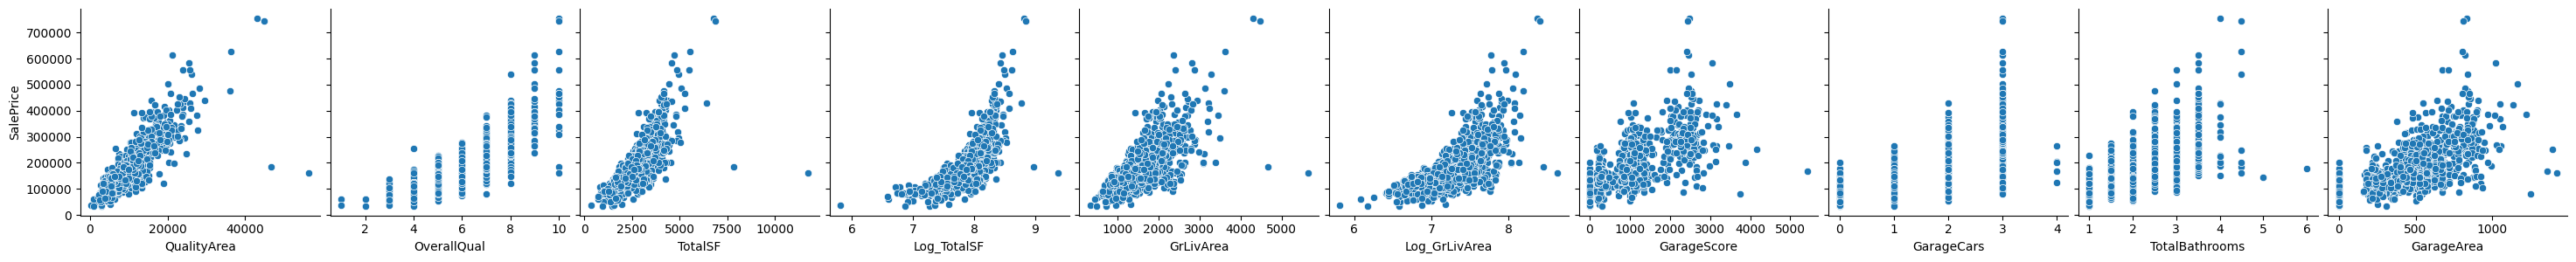

In [339]:
# Pairplotting the top 10 features against the target variable
sns.pairplot(df_train, x_vars=top_features, y_vars=['SalePrice'], height=3)
plt.show()

In [340]:
X = df_train.drop(columns=[TARGET_COLUMN])
y = df_train[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [341]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_cols),
    ('cat', cat_transformer, categorical_cols)
])

In [342]:
baseline = Pipeline([('preprocessor', preprocessor), ('regressor', DummyRegressor(strategy='mean'))])
baseline.fit(X_train, y_train)
print(f"Baseline R^2: {baseline.score(X_test, y_test):.4f}")

Baseline R^2: -0.0009


In [343]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 300],
    'regressor__learning_rate': [0.03, 0.1],
    'regressor__max_depth': [2, 3],
}

grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV R^2: {grid_search.best_score_:.4f}")

Best params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 300}
Best CV R^2: 0.8705


In [344]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)

print(f"Test R^2   : {r2_score(y_test, predictions):.4f}")
print(f"Test RMSE  : {root_mean_squared_error(y_test, predictions):.2f}")
print(f"Test MAE   : {mean_absolute_error(y_test, predictions):.2f}")
print(f"(Baseline R^2 was: {baseline.score(X_test, y_test):.4f})")

Test R^2   : 0.8985
Test RMSE  : 27907.30
Test MAE   : 16142.09
(Baseline R^2 was: -0.0009)


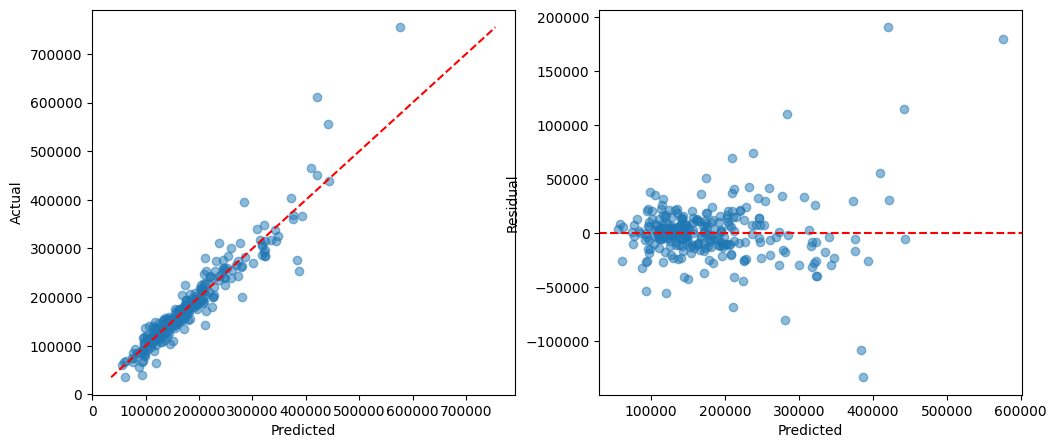

In [345]:
residuals = y_test - predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(predictions, y_test, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[1].scatter(predictions, residuals, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
plt.show()

In [346]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['regressor'].feature_importances_
pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(20)

,feature,importance
44,num__QualityArea,0.463430
3,num__OverallQual,0.134585
36,num__TotalSF,0.081390
52,num__Log_TotalSF,0.038658
8,num__BsmtFinSF1,0.030188
13,num__2ndFlrSF,0.020626
197,cat__BsmtQual_Ex,0.019695
25,num__GarageCars,0.017881
262,cat__GarageFinish_Unf,0.016272
46,num__GarageScore,0.014549


In [347]:
final_model = grid_search.best_estimator_
final_model.fit(X, y)

submission_predictions = final_model.predict(df_test)
pd.DataFrame({'Id': test_ids, TARGET_COLUMN: submission_predictions}).to_csv(SUBMISSION_OUTPUT_PATH, index=False)
print("Submission saved.")

Submission saved.
